In [1]:
from mpl_toolkits.axisartist.axislines import SubplotZero
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import unique
from pandas import read_csv
import seaborn as sns
sns.set(style='ticks')
import matplotlib.cm as cm
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [2]:
url = 'https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv'
df = read_csv(url)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


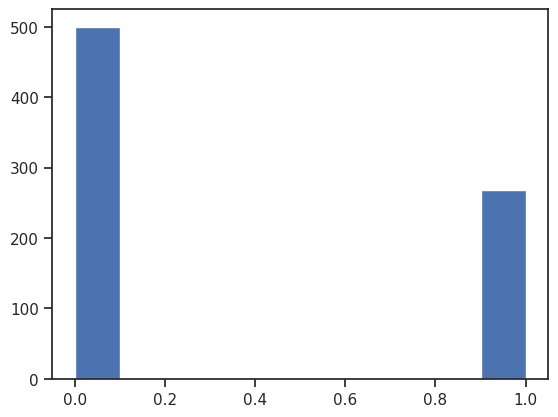

In [3]:
plt.hist(df['Outcome'])
plt.show()

# Memisahkan Label dan Feature

In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Membagi Data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)
print(f"Train-test split: train={len(X_train)}, test={len(X_test)}")

Train-test split: train=537, test=231


# Preprocessing

In [6]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns
)

# Imbalance

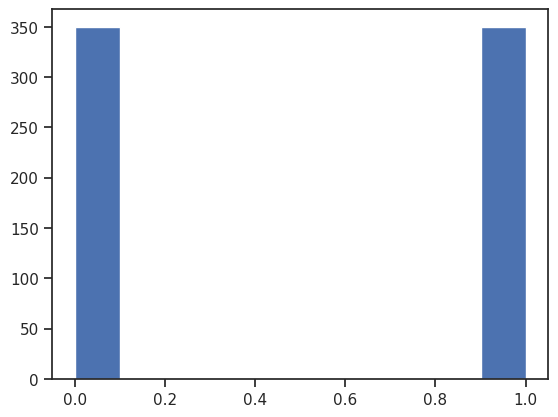

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_smote_resampled, y_smote_resampled = smote.fit_resample(X_train_scaled, y_train)

X_smote = pd.DataFrame(X_smote_resampled, columns=X.columns)
y_smote = pd.DataFrame(y_smote_resampled, columns=[y.name])

df_balanced = pd.concat([X_smote, y_smote], axis=1)
df_balanced.head()
plt.hist(df_balanced['Outcome'])
plt.show()

# Seleksi Fitur

HASIL SELEKSI FITUR
                   Fitur       Skor
                 Glucose 162.083010
                     BMI  62.827427
                     Age  51.487310
             Pregnancies  36.676938
DiabetesPedigreeFunction  20.394443
                 Insulin  12.194409
           SkinThickness   1.349777
           BloodPressure   1.318209


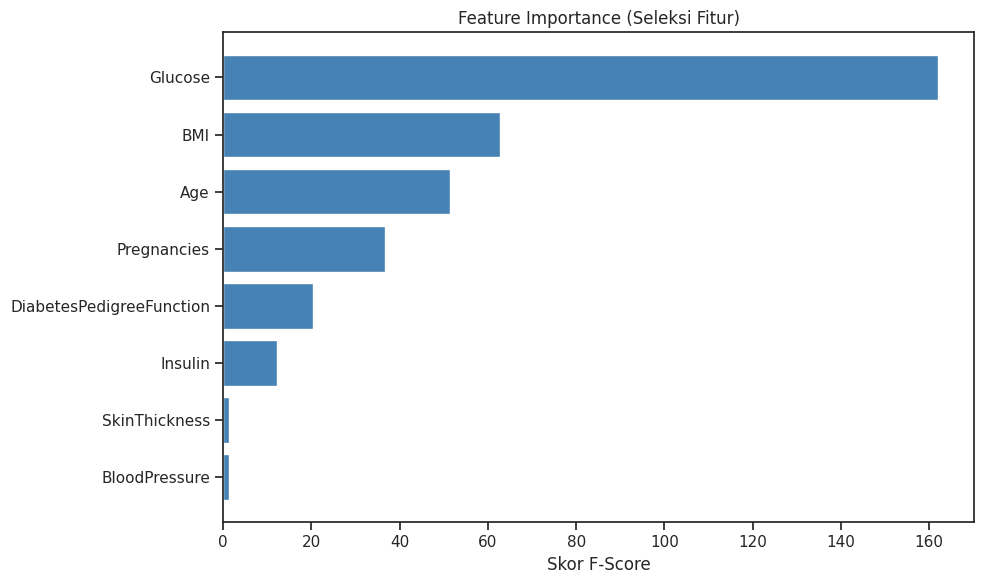

REKOMENDASI FITUR TERBAIK
1 Fitur Terbaik: Glucose
3 Fitur Terbaik: ['Glucose', 'BMI', 'Age']
5 Fitur Terbaik: ['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction']
Semua Fitur (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [14]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
import matplotlib.pyplot as plt

# Seleksi fitur dengan ANOVA F-test
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_smote, y_smote.values.ravel())

# Hasil skor setiap fitur
scores = pd.DataFrame({
    'Fitur': X.columns,
    'Skor': selector.scores_
}).sort_values('Skor', ascending=False)

print("HASIL SELEKSI FITUR")
print(scores.to_string(index=False))

# Visualisasi feature importance
plt.figure(figsize=(10, 6))
plt.barh(scores['Fitur'], scores['Skor'], color='steelblue')
plt.xlabel('Skor F-Score')
plt.title('Feature Importance (Seleksi Fitur)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("REKOMENDASI FITUR TERBAIK")

top1 = scores.iloc[0]['Fitur']
top3 = scores.iloc[:3]['Fitur'].tolist()
top5 = scores.iloc[:5]['Fitur'].tolist()

print(f"1 Fitur Terbaik: {top1}")
print(f"3 Fitur Terbaik: {top3}")
print(f"5 Fitur Terbaik: {top5}")
print(f"Semua Fitur (8): {list(X.columns)}")

# HPO Algoritma K-NN

In [ ]:
param_grid = {
    'weights':['uniform','distance'], 'n_neighbors':[3,5,7,9,11,13,15], 'metric':['euclidean','manhattan','chebyshev','minkowski']
}

classifier_knn = GridSearchCV(KNeighborsClassifier(), param_grid, scoring='recall_macro', cv=5, refit = True, verbose = 3)

y_smote = np.array(y_smote).ravel()

classifier_knn.fit(X_smote, y_smote)

print('parameter terbaik:',classifier_knn.best_params_)
print(classifier_knn.best_estimator_)

Fitting 5 folds for each of 56 candidates, totalling 280 fits
[CV 1/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=0.743 total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=0.779 total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=0.821 total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=0.814 total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=3, weights=uniform;, score=0.829 total time=   0.0s
[CV 1/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.743 total time=   0.0s
[CV 2/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.814 total time=   0.0s
[CV 3/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.836 total time=   0.0s
[CV 4/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.829 total time=   0.0s
[CV 5/5] END metric=euclidean, n_neighbors=3, weights=distance;, score=0.843 to

              precision    recall  f1-score   support

           0       0.81      0.74      0.77       150
           1       0.59      0.68      0.63        81

    accuracy                           0.72       231
   macro avg       0.70      0.71      0.70       231
weighted avg       0.73      0.72      0.72       231



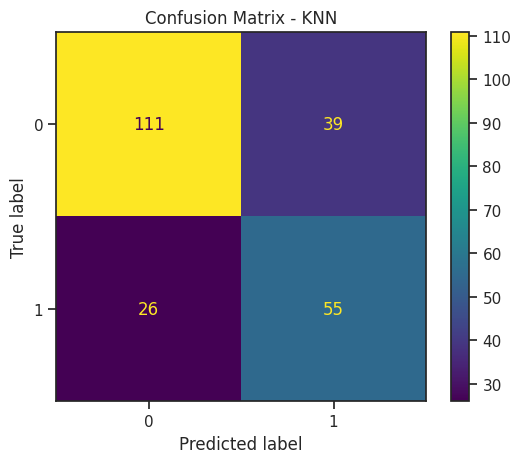

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

pred_knn = classifier_knn.predict(X_test_scaled)
print(classification_report(y_test, pred_knn))

cm = confusion_matrix(y_test, pred_knn)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion Matrix - KNN')
plt.show()

# HPO Algoritma SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# y_smote = y_smote.squeeze()

param_grid = {'C': [1, 10],'gamma': [0.01, 0.001],'kernel': ['rbf']}

classifier_svm = GridSearchCV(
    SVC(),
    param_grid,
    scoring='accuracy',
    cv=5,
    refit=True,
    verbose=4
)

classifier_svm.fit(X_smote, y_smote)

print('parameter terbaik:',classifier_svm.best_params_)
print(classifier_svm.best_estimator_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.736 total time=   0.0s
[CV 2/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.743 total time=   0.0s
[CV 3/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.779 total time=   0.0s
[CV 4/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.757 total time=   0.0s
[CV 5/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.700 total time=   0.0s
[CV 1/5] END ......C=1, gamma=0.001, kernel=rbf;, score=0.743 total time=   0.0s
[CV 2/5] END ......C=1, gamma=0.001, kernel=rbf;, score=0.764 total time=   0.0s
[CV 3/5] END ......C=1, gamma=0.001, kernel=rbf;, score=0.700 total time=   0.0s
[CV 4/5] END ......C=1, gamma=0.001, kernel=rbf;, score=0.743 total time=   0.0s
[CV 5/5] END ......C=1, gamma=0.001, kernel=rbf;, score=0.679 total time=   0.0s
[CV 1/5] END ......C=10, gamma=0.01, kernel=rbf;, score=0.743 total time=   0.0s
[CV 2/5] END ......C=10, gamma=0.01, kernel=rbf;,

              precision    recall  f1-score   support

           0       0.85      0.80      0.82       150
           1       0.66      0.73      0.69        81

    accuracy                           0.77       231
   macro avg       0.75      0.76      0.76       231
weighted avg       0.78      0.77      0.78       231



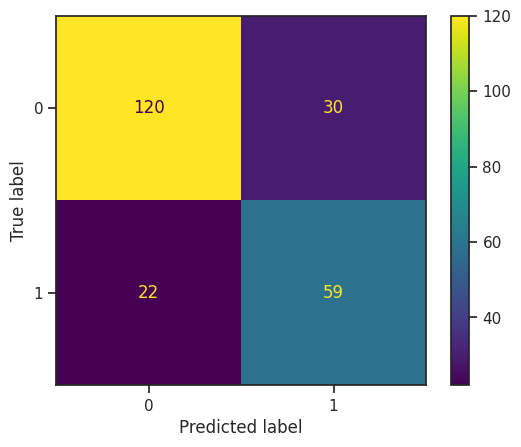

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

pred_svm = classifier_svm.predict(X_test_scaled)
print(classification_report(y_test, pred_svm))

cm = confusion_matrix(y_test, pred_svm)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# HPO Algoritma Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

classifier_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid_dt,
    scoring='recall_macro',
    cv=5,
    refit=True,
    verbose=3
)

classifier_dt.fit(X_smote, y_smote)

print('Parameter terbaik:', classifier_dt.best_params_)
print(classifier_dt.best_estimator_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.650 total time=   0.1s
[CV 2/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.686 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.743 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.771 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2;, score=0.750 total time=   0.1s
[CV 1/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.650 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.686 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5;, score=0.764 total time=  

              precision    recall  f1-score   support

           0       0.86      0.72      0.78       150
           1       0.60      0.78      0.68        81

    accuracy                           0.74       231
   macro avg       0.73      0.75      0.73       231
weighted avg       0.77      0.74      0.75       231



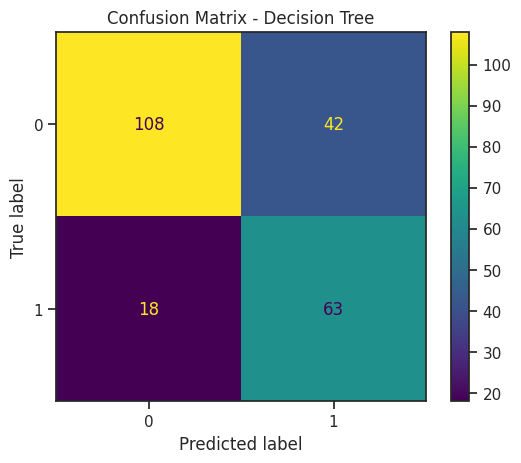

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_dt = classifier_dt.predict(X_test_scaled)

print(classification_report(y_test, pred_dt))

cm_dt = confusion_matrix(y_test, pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title('Confusion Matrix - Decision Tree')
plt.show()

# HPO Algoritma NN

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'max_iter': [1000, 1500, 2000, 3000]
}

classifier_mlp = GridSearchCV(
    MLPClassifier(random_state=0, early_stopping=True, validation_fraction=0.1),
    param_grid_mlp,
    scoring='recall_macro',
    cv=5,
    refit=True,
    verbose=3
)

if y_smote.ndim > 1:
    y_smote_1d = y_smote.ravel()
else:
    y_smote_1d = y_smote

classifier_mlp.fit(X_smote, y_smote_1d)

print('Parameter terbaik:', classifier_mlp.best_params_)
print(classifier_mlp.best_estimator_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.657 total time=   0.0s
[CV 2/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.757 total time=   0.1s
[CV 3/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.736 total time=   0.1s
[CV 4/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.543 total time=   0.0s
[CV 5/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=adam;, score=0.686 total time=   0.1s
[CV 1/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=sgd;, score=0.629 total time=   0.1s
[CV 2/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=sgd;, score=0.721 total time=   0.1s
[CV 3/5] END activation=relu, hidden_layer_sizes=(50,), max_iter=1000, solver=sgd;, score=0.571 total time=   0.0s
[CV 4/5] END 

              precision    recall  f1-score   support

           0       0.85      0.75      0.80       150
           1       0.62      0.77      0.69        81

    accuracy                           0.75       231
   macro avg       0.74      0.76      0.74       231
weighted avg       0.77      0.75      0.76       231



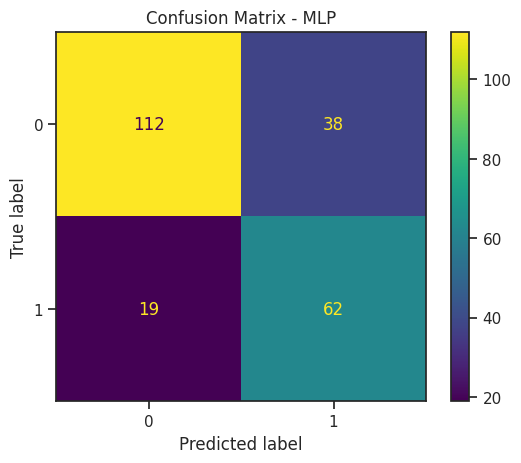

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_mlp = classifier_mlp.predict(X_test_scaled)

print(classification_report(y_test, pred_mlp))

cm_mlp = confusion_matrix(y_test, pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp)
disp_mlp.plot()
plt.title('Confusion Matrix - MLP')
plt.show()

# Save Model

In [ ]:
import joblib

filename = '/content/Tubes_Dasildat_SVM.sav'
joblib.dump(classifier_svm.best_estimator_, filename)

loaded_model = joblib.load(filename)
print(loaded_model)

print('Hail model menggunakan yang sudah di simpan:', loaded_model.score(X_test_scaled, y_test))
print('Hail model menggunakan hasil training lansung:', classifier_svm.score(X_test_scaled, y_test))

SVC(C=10, gamma=0.01)
Hail model menggunakan yang sudah di simpan: 0.7748917748917749
Hail model menggunakan hasil training lansung: 0.7748917748917749


In [ ]:
import joblib

knn_filename = '/content/Tubes_Dasildat_KNN.sav'
joblib.dump(classifier_knn.best_estimator_, knn_filename)

loaded_knn_model = joblib.load(knn_filename)
print(loaded_knn_model)

print('Hail model menggunakan yang sudah di simpan:', loaded_knn_model.score(X_test_scaled, y_test))
print('Hail model menggunakan hasil training lansung:', classifier_knn.score(X_test_scaled, y_test))

KNeighborsClassifier(metric='euclidean', n_neighbors=3, weights='distance')
Hail model menggunakan yang sudah di simpan: 0.7186147186147186
Hail model menggunakan hasil training lansung: 0.7095061728395062


In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

dt_filename = '/content/Tubes_Dasildat_DecisionTree.sav'
joblib.dump(classifier_dt.best_estimator_, dt_filename)

loaded_dt = joblib.load(dt_filename)
print(loaded_dt)

print('Hail model menggunakan yang sudah di simpan:', loaded_dt.score(X_test_scaled, y_test))
print('Hail model menggunakan hasil training lansung:', classifier_dt.score(X_test_scaled, y_test))

DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, random_state=0)
Hail model menggunakan yang sudah di simpan: 0.7402597402597403
Hail model menggunakan hasil training lansung: 0.7488888888888889


In [ ]:
import joblib

data_filename = '/content/Tubes_Dasildat_NN.sav'
joblib.dump(classifier_mlp.best_estimator_, data_filename)

loaded_mlp = joblib.load(data_filename)
print(loaded_mlp)

print('Hail model menggunakan yang sudah di simpan:', loaded_mlp.score(X_test_scaled, y_test))
print('Hail model menggunakan hasil training lansung:', classifier_mlp.score(X_test_scaled, y_test))

MLPClassifier(activation='tanh', early_stopping=True,
              hidden_layer_sizes=(50, 50), max_iter=1000, random_state=0)
Hail model menggunakan yang sudah di simpan: 0.7532467532467533
Hail model menggunakan hasil training lansung: 0.7560493827160494


In [7]:
import joblib

scaler_filename = '/content/Tubes_Dasildat_Scaler.sav'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to {scaler_filename}")

Scaler saved to /content/Tubes_Dasildat_Scaler.sav


# Perbandingan Akurasi Model

=== Perbandingan Performa Model ===
                 Model  Accuracy  Precision  Recall  F1-Score
Ranking                                                      
1                  SVM    0.7749     0.7540  0.7642    0.7580
2                  KNN    0.7532     0.7292  0.7305    0.7298
3                  MLP    0.7532     0.7375  0.7560    0.7411
4        Decision Tree    0.7403     0.7286  0.7489    0.7300


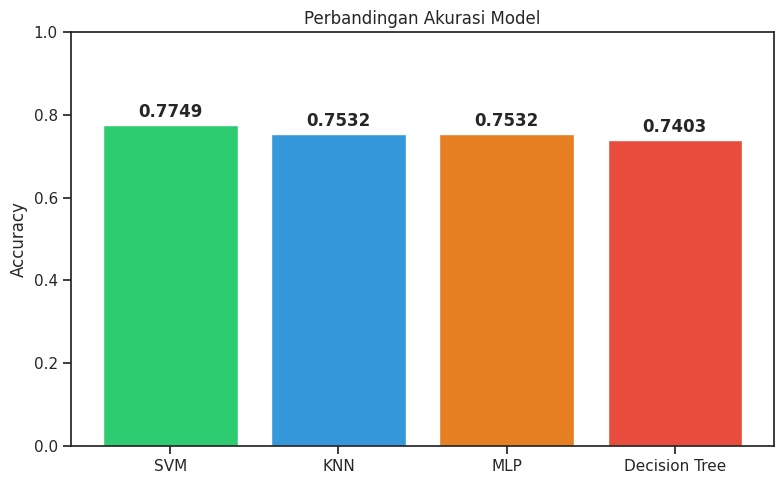


Model terbaik: SVM dengan akurasi 0.7749


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Prediksi dari setiap model
pred_knn  = classifier.predict(X_test_scaled)
pred_svm  = classifier_svm.predict(X_test_scaled)
pred_dt   = classifier_dt.predict(X_test_scaled)
pred_mlp  = classifier_mlp.predict(X_test_scaled)

# Hitung metrik
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='macro'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='macro'), 4),
    }

results = [
    get_metrics(y_test, pred_knn,  'KNN'),
    get_metrics(y_test, pred_svm,  'SVM'),
    get_metrics(y_test, pred_dt,   'Decision Tree'),
    get_metrics(y_test, pred_mlp,  'MLP'),
]

df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1  # ranking mulai dari 1
df_results.index.name = 'Ranking'

print('=== Perbandingan Performa Model ===')
print(df_results.to_string())

# Bar chart perbandingan akurasi
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
bars = ax.bar(df_results['Model'], df_results['Accuracy'], color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Akurasi Model')
for bar, val in zip(bars, df_results['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

best = df_results.iloc[0]
print(f"\nModel terbaik: {best['Model']} dengan akurasi {best['Accuracy']}")

# Download File

In [ ]:
from google.colab import files

files.download('/content/Tubes_Dasildat_SVM.sav')
files.download('/content/Tubes_Dasildat_KNN.sav')
files.download('/content/Tubes_Dasildat_DecisionTree.sav')
files.download('/content/Tubes_Dasildat_NN.sav')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Download scaler
# files.download('/content/Tubes_Dasildat_Scaler.sav') # This line caused an error because the scaler was not saved.

In [8]:
from google.colab import files

# Download scaler
files.download('/content/Tubes_Dasildat_Scaler.sav')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>